In [9]:
nifty = yf.Ticker("^NSEI")


In [10]:
nifty = nifty.history(period="max")

In [11]:
nifty

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0,0.0,0.0
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0,0.0,0.0
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0,0.0,0.0
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0,0.0,0.0
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-02-27 00:00:00+05:30,25459.849609,25476.400391,25141.300781,25178.650391,438900,0.0,0.0
2026-03-02 00:00:00+05:30,24659.250000,24989.349609,24603.500000,24865.699219,519200,0.0,0.0
2026-03-04 00:00:00+05:30,24388.800781,24602.449219,24305.400391,24480.500000,599000,0.0,0.0


In [14]:
nifty.to_csv("nifty50_maxdata.csv")

In [15]:
nifty.index

DatetimeIndex(['2007-09-17 00:00:00+05:30', '2007-09-18 00:00:00+05:30',
               '2007-09-19 00:00:00+05:30', '2007-09-20 00:00:00+05:30',
               '2007-09-21 00:00:00+05:30', '2007-09-24 00:00:00+05:30',
               '2007-09-25 00:00:00+05:30', '2007-09-26 00:00:00+05:30',
               '2007-09-27 00:00:00+05:30', '2007-09-28 00:00:00+05:30',
               ...
               '2026-02-20 00:00:00+05:30', '2026-02-23 00:00:00+05:30',
               '2026-02-24 00:00:00+05:30', '2026-02-25 00:00:00+05:30',
               '2026-02-26 00:00:00+05:30', '2026-02-27 00:00:00+05:30',
               '2026-03-02 00:00:00+05:30', '2026-03-04 00:00:00+05:30',
               '2026-03-05 00:00:00+05:30', '2026-03-06 00:00:00+05:30'],
              dtype='datetime64[ns, Asia/Kolkata]', name='Date', length=4531, freq=None)

<Axes: xlabel='Date'>

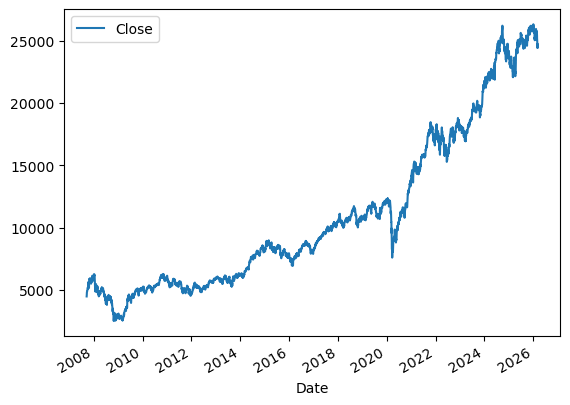

In [16]:
nifty.plot.line(y="Close" , use_index=True)

In [17]:
del nifty["Dividends"]
del nifty["Stock Splits"]

In [19]:
nifty["Tomorrow"] = nifty["Close"].shift(-1)

In [20]:
nifty

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0,4546.200195
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0,4732.350098
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0,4747.549805
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0,4837.549805
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0,4932.200195
...,...,...,...,...,...,...
2026-02-27 00:00:00+05:30,25459.849609,25476.400391,25141.300781,25178.650391,438900,24865.699219
2026-03-02 00:00:00+05:30,24659.250000,24989.349609,24603.500000,24865.699219,519200,24480.500000
2026-03-04 00:00:00+05:30,24388.800781,24602.449219,24305.400391,24480.500000,599000,24765.900391


In [22]:
nifty["Target"] = (nifty["Tomorrow"] > nifty["Close"]).astype(int)

In [23]:
nifty

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0,4546.200195,1
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0,4732.350098,1
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0,4747.549805,1
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0,4837.549805,1
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0,4932.200195,1
...,...,...,...,...,...,...,...
2026-02-27 00:00:00+05:30,25459.849609,25476.400391,25141.300781,25178.650391,438900,24865.699219,0
2026-03-02 00:00:00+05:30,24659.250000,24989.349609,24603.500000,24865.699219,519200,24480.500000,0
2026-03-04 00:00:00+05:30,24388.800781,24602.449219,24305.400391,24480.500000,599000,24765.900391,1


In [25]:
#  The next thing we will do, There is lot of historical Data in this Data Frame and usually it is great for predicting 
# something but in stock market data if we go back too far the market could have shifted fundamentally and some of that old 
# data may not be usefull in making future prediction. 
# So we will remove all data before 2010.

nifty = nifty.loc["2010-01-01":].copy()

In [26]:
nifty

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
2010-01-04 00:00:00+05:30,5200.899902,5238.450195,5167.100098,5232.200195,0,5277.899902,1
2010-01-05 00:00:00+05:30,5277.149902,5288.350098,5242.399902,5277.899902,0,5281.799805,1
2010-01-06 00:00:00+05:30,5278.149902,5310.850098,5260.049805,5281.799805,0,5263.100098,0
2010-01-07 00:00:00+05:30,5281.799805,5302.549805,5244.750000,5263.100098,0,5244.750000,0
2010-01-08 00:00:00+05:30,5264.250000,5276.750000,5234.700195,5244.750000,0,5249.399902,1
...,...,...,...,...,...,...,...
2026-02-27 00:00:00+05:30,25459.849609,25476.400391,25141.300781,25178.650391,438900,24865.699219,0
2026-03-02 00:00:00+05:30,24659.250000,24989.349609,24603.500000,24865.699219,519200,24480.500000,0
2026-03-04 00:00:00+05:30,24388.800781,24602.449219,24305.400391,24480.500000,599000,24765.900391,1


In [28]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

train = nifty.iloc[:-100]
test = nifty.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
precision_score(test["Target"], preds)

0.0

<Axes: xlabel='Date'>

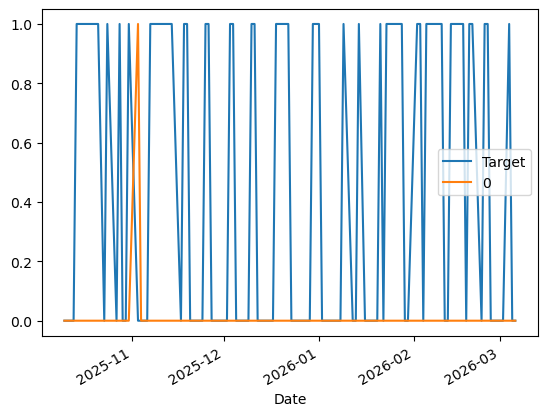

In [30]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()

In [31]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [32]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    
    return pd.concat(all_predictions)

In [33]:
predictions = backtest(nifty, model, predictors)

In [34]:
predictions["Predictions"].value_counts()

Predictions
0    1031
1     442
Name: count, dtype: int64

In [35]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5520361990950227

In [36]:
predictions["Target"].value_counts() / predictions.shape[0]

Target
1    0.549219
0    0.450781
Name: count, dtype: float64

In [37]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
    rolling_averages = nifty.rolling(horizon).mean()
    
    ratio_column = f"Close_Ratio_{horizon}"
    nifty[ratio_column] = nifty["Close"] / rolling_averages["Close"]
    
    trend_column = f"Trend_{horizon}"
    nifty[trend_column] = nifty.shift(1).rolling(horizon).sum()["Target"]
    
    new_predictors+= [ratio_column, trend_column]

In [38]:
nifty = nifty.dropna(subset=nifty.columns[nifty.columns != "Tomorrow"])

In [39]:
nifty

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
2014-01-29 00:00:00+05:30,6161.000000,6170.450195,6109.799805,6120.250000,146700,6073.700195,0,0.999510,0.0,0.987304,1.0,0.986852,25.0,1.031750,121.0,1.106406,505.0
2014-01-30 00:00:00+05:30,6067.000000,6082.850098,6027.250000,6073.700195,208100,6089.500000,1,0.996183,0.0,0.988468,0.0,0.979961,24.0,1.023903,120.0,1.097833,504.0
2014-01-31 00:00:00+05:30,6082.750000,6097.850098,6067.350098,6089.500000,146700,6001.799805,0,1.001299,1.0,0.996790,1.0,0.982943,25.0,1.026557,120.0,1.100528,504.0
2014-02-03 00:00:00+05:30,6058.799805,6074.850098,5994.450195,6001.799805,134900,6000.899902,0,0.992747,1.0,0.986765,1.0,0.969343,25.0,1.011805,120.0,1.084534,504.0
2014-02-04 00:00:00+05:30,5947.600098,6017.799805,5933.299805,6000.899902,183300,6022.399902,1,0.999925,0.0,0.990700,1.0,0.969684,25.0,1.011691,119.0,1.084223,504.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-27 00:00:00+05:30,25459.849609,25476.400391,25141.300781,25178.650391,438900,24865.699219,0,0.993727,1.0,0.988985,3.0,0.977614,29.0,1.009404,131.0,1.180075,530.0
2026-03-02 00:00:00+05:30,24659.250000,24989.349609,24603.500000,24865.699219,519200,24480.500000,0,0.993747,0.0,0.983238,2.0,0.966163,29.0,0.996488,131.0,1.164998,530.0
2026-03-04 00:00:00+05:30,24388.800781,24602.449219,24305.400391,24480.500000,599000,24765.900391,1,0.992194,0.0,0.975288,2.0,0.952154,28.0,0.980747,131.0,1.146541,530.0


In [40]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [41]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >=.6] = 1
    preds[preds <.6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [42]:
predictions = backtest(nifty, model, new_predictors)

In [43]:
predictions["Predictions"].value_counts()

Predictions
0.0    421
1.0     52
Name: count, dtype: int64

In [44]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5769230769230769

In [45]:
predictions["Target"].value_counts() / predictions.shape[0]

Target
1    0.511628
0    0.488372
Name: count, dtype: float64

In [46]:
predictions

,Target,Predictions
Date,,
2024-04-09 00:00:00+05:30,1,0.0
2024-04-10 00:00:00+05:30,0,0.0
2024-04-12 00:00:00+05:30,0,1.0
2024-04-15 00:00:00+05:30,0,1.0
2024-04-16 00:00:00+05:30,0,0.0
...,...,...
2026-02-27 00:00:00+05:30,0,0.0
2026-03-02 00:00:00+05:30,0,0.0
2026-03-04 00:00:00+05:30,1,1.0
